In [1]:
# Imports.
import numpy as np;
import xarray as xr;
import matplotlib.pyplot as plt;
import h5_reader_xr as reader;
import gysela_utilities as gys_utils;
import phi2D_utilities as utils;
import phi2D_analytical as analytical;
import gam_specialised.damping as damping;
from scipy.signal import find_peaks;

# Styling.
plt.style.use("ggplot");

In [ ]:
# Test inputs - delete when done!
perturbed_case_directory_path = "/zhisongqu_data/seth/GYSELA/raw/batch_11/DN_DELTASCAN_A3_PERTURB_-0.1";
quiescent_case_directory_path = None;
perturbed_case_data_arrays = reader.fetch_phi2D_data(perturbed_case_directory_path, parallelise = True);
quiescent_case_data_arrays = reader.fetch_phi2D_data(quiescent_case_directory_path, parallelise = True) if quiescent_case_directory_path is not None else None;
dt_diag = reader.fetch_dt_diag(perturbed_case_directory_path);
jacobian_dictionary = reader.fetch_jacobian(perturbed_case_directory_path);

Found 1201 files in the directory. Loading with 16 workers...


[Parallel(n_jobs=16)]: Using backend LokyBackend with 16 concurrent workers.
[Parallel(n_jobs=16)]: Done  18 tasks      | elapsed:    1.0s
[Parallel(n_jobs=16)]: Done 368 tasks      | elapsed:    2.2s
[Parallel(n_jobs=16)]: Done 1170 out of 1201 | elapsed:    5.4s remaining:    0.1s
[Parallel(n_jobs=16)]: Done 1201 out of 1201 | elapsed:    5.5s finished


Finished compiling data from all files in the directory.


In [3]:
# All requisite data.
effective_radius_simple = utils.find_gam_effective_radius_simple(perturbed_case_data_arrays, jacobian_dictionary, quiescent_case_data_arrays, skip_initial_entries = 0.1);
GAM_frequency = utils.extract_gam_frequency(perturbed_case_data_arrays, dt_diag, jacobian_dictionary, effective_radius_simple);
physical_data, statistical_data = damping.scan_gam_damping_over_radius(
	perturbed_case_data_arrays,
	dt_diag,
	jacobian_dictionary,
	GAM_frequency,
	quiescent_phi2D_list = quiescent_case_data_arrays,
	skip_peaks = [1, 3]);

<xarray.DataArray (r: 204)> Size: 2kB
array([0.01682599, 0.0166363 , 0.01644245, 0.01624472, 0.01604329,
       0.01583843, 0.0156304 , 0.01541947, 0.01520586, 0.01498984,
       0.01477169, 0.01455169, 0.01433009, 0.01410716, 0.01388317,
       0.01365839, 0.01343307, 0.01320747, 0.01298185, 0.01275646,
       0.01253153, 0.01230731, 0.01208404, 0.01186194, 0.01164123,
       0.01142215, 0.0112049 , 0.01098968, 0.0107767 , 0.01056614,
       0.01035819, 0.01015302, 0.00995079, 0.00975166, 0.00955577,
       0.00936326, 0.00917424, 0.00898883, 0.00880712, 0.00862919,
       0.00845513, 0.00828498, 0.00811879, 0.00795659, 0.00779839,
       0.0076442 , 0.007494  , 0.00734778, 0.00720551, 0.00706716,
       0.00693266, 0.00680194, 0.00667492, 0.00655151, 0.00643161,
       0.00631512, 0.00620194, 0.00609198, 0.0059851 , 0.00588118,
       0.0057801 , 0.00568175, 0.00558603, 0.00549284, 0.00540207,
       0.00531365, 0.0052275 , 0.00514353, 0.00506166, 0.00498183,
       0.004904  , 0.004

Setting minimum distance for interpolation to be  12.3 in code units.
Found 47 peaks.
Plotting...


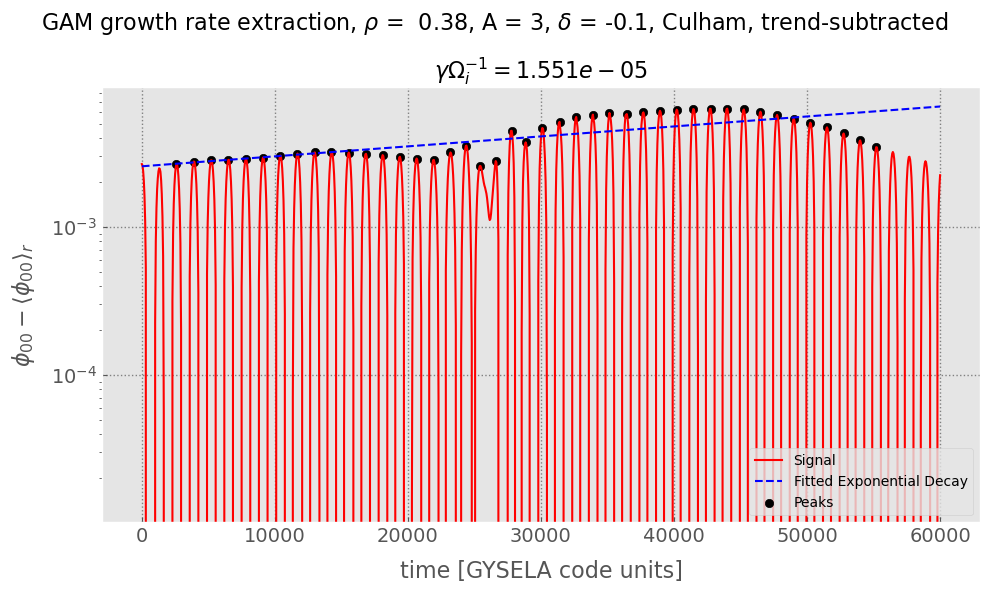

In [6]:
damping.plot_gam_damping(
	perturbed_case_data_arrays, 
	dt_diag, 
	jacobian_dictionary, 
	GAM_frequency, 
	effective_radius = 0.38, 
	quiescent_phi2D_list = quiescent_case_data_arrays, 
	skip_peaks = [1, 3],
	title_suffix = rf"A = 3, $\delta$ = -0.1, Culham, trend-subtracted");

/home/thur0011/GYSELA/custom_scripts/GYSELA_utils/post-processing/scripts/gam_specialised/damping.py:170: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax1.legend(loc="upper left");


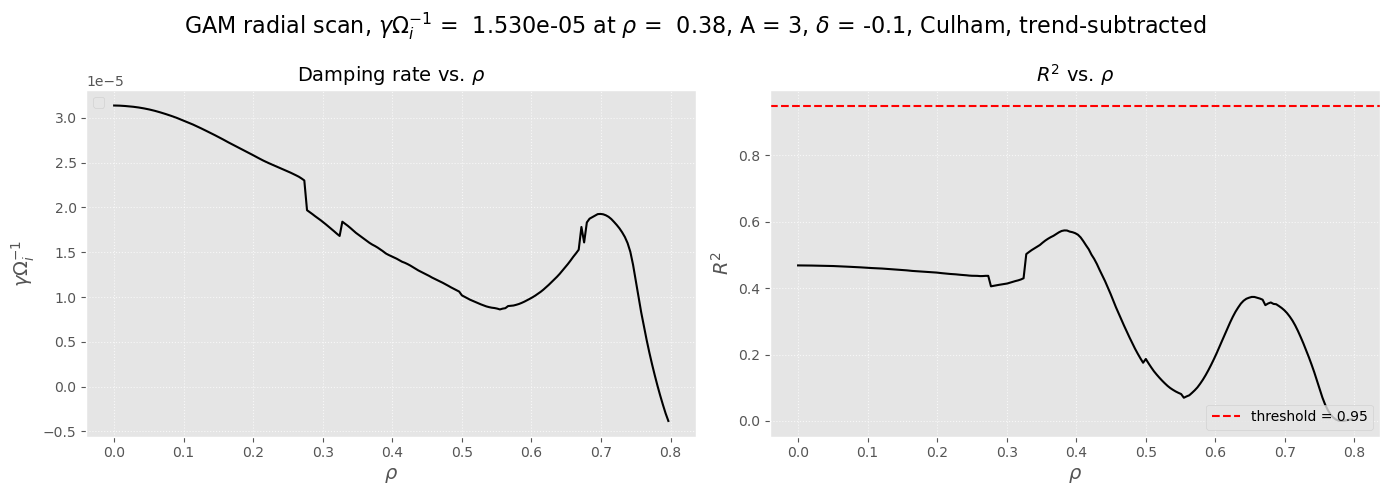

In [5]:
damping.plot_gam_damping_radial_scan(physical_data, statistical_data, title_suffix = fr"A = 3, $\delta$ = -0.1, Culham, trend-subtracted");